2026-01-27 08:32:19,192 - pipeline - INFO - Configuration validated successfully
2026-01-27 08:32:19,201 - pipeline - INFO - Directories created
2026-01-27 08:32:19,360 - pipeline - INFO - Spark Session Created: 3.5.0
2026-01-27 08:32:19,362 - visualizations - INFO - Visualizations will be saved to: visualizations
2026-01-27 08:32:19,363 - pipeline - INFO - All modules initialized
2026-01-27 08:32:19,364 - pipeline - INFO - 
2026-01-27 08:32:19,365 - pipeline - INFO -  TMDB MOVIE ANALYSIS PIPELINE - PYSPARK IMPLEMENTATION
2026-01-27 08:32:19,366 - pipeline - INFO - ======================================================================

2026-01-27 08:32:19,367 - pipeline - INFO - ======================================================================
2026-01-27 08:32:19,368 - pipeline - INFO - STEP 1: DATA EXTRACTION FROM TMDB API
2026-01-27 08:32:19,369 - pipeline - INFO - ======================================================================
2026-01-27 08:32:19,371 - data_extraction - 

2026-01-27 08:32:29,587 - data_transformations - INFO - Initial DataFrame: 18 rows × 28 columns
2026-01-27 08:32:29,588 - data_transformations - INFO - Dropping 5 irrelevant columns
2026-01-27 08:32:29,601 - data_transformations - INFO - Extracting nested JSON fields...
2026-01-27 08:32:29,968 - data_transformations - INFO - Sample data after nested field extraction:
+----------------------------+----------------------------------------+-----------------------+-----------------------+
|                       title|                                  genres|  belongs_to_collection|               director|
+----------------------------+----------------------------------------+-----------------------+-----------------------+
|           Avengers: Endgame|        Adventure|Science Fiction|Action|The Avengers Collection|Anthony Russo|Joe Russo|
|                      Avatar|Action|Adventure|Fantasy|Science Fiction|      Avatar Collection|          James Cameron|
|Star Wars: The Force Awakens|

2026-01-27 08:32:49,593 - pipeline - INFO - All analysis results saved
2026-01-27 08:32:49,595 - pipeline - INFO - ======================================================================
2026-01-27 08:32:49,596 - pipeline - INFO - STEP 4: DATA VISUALIZATION
2026-01-27 08:32:49,597 - pipeline - INFO - ======================================================================
2026-01-27 08:32:49,598 - visualizations - INFO - ============================================================
2026-01-27 08:32:49,600 - visualizations - INFO - Generating All Visualizations
2026-01-27 08:32:49,602 - visualizations - INFO - ============================================================
2026-01-27 08:32:49,604 - visualizations - INFO - Creating Revenue vs Budget visualization...
2026-01-27 08:32:50,111 - visualizations - INFO - Saved: visualizations/revenue_vs_budget.png
2026-01-27 08:32:50,112 - visualizations - INFO - Creating ROI distribution visualization...
2026-01-27 08:32:50,648 - visualizations - IN

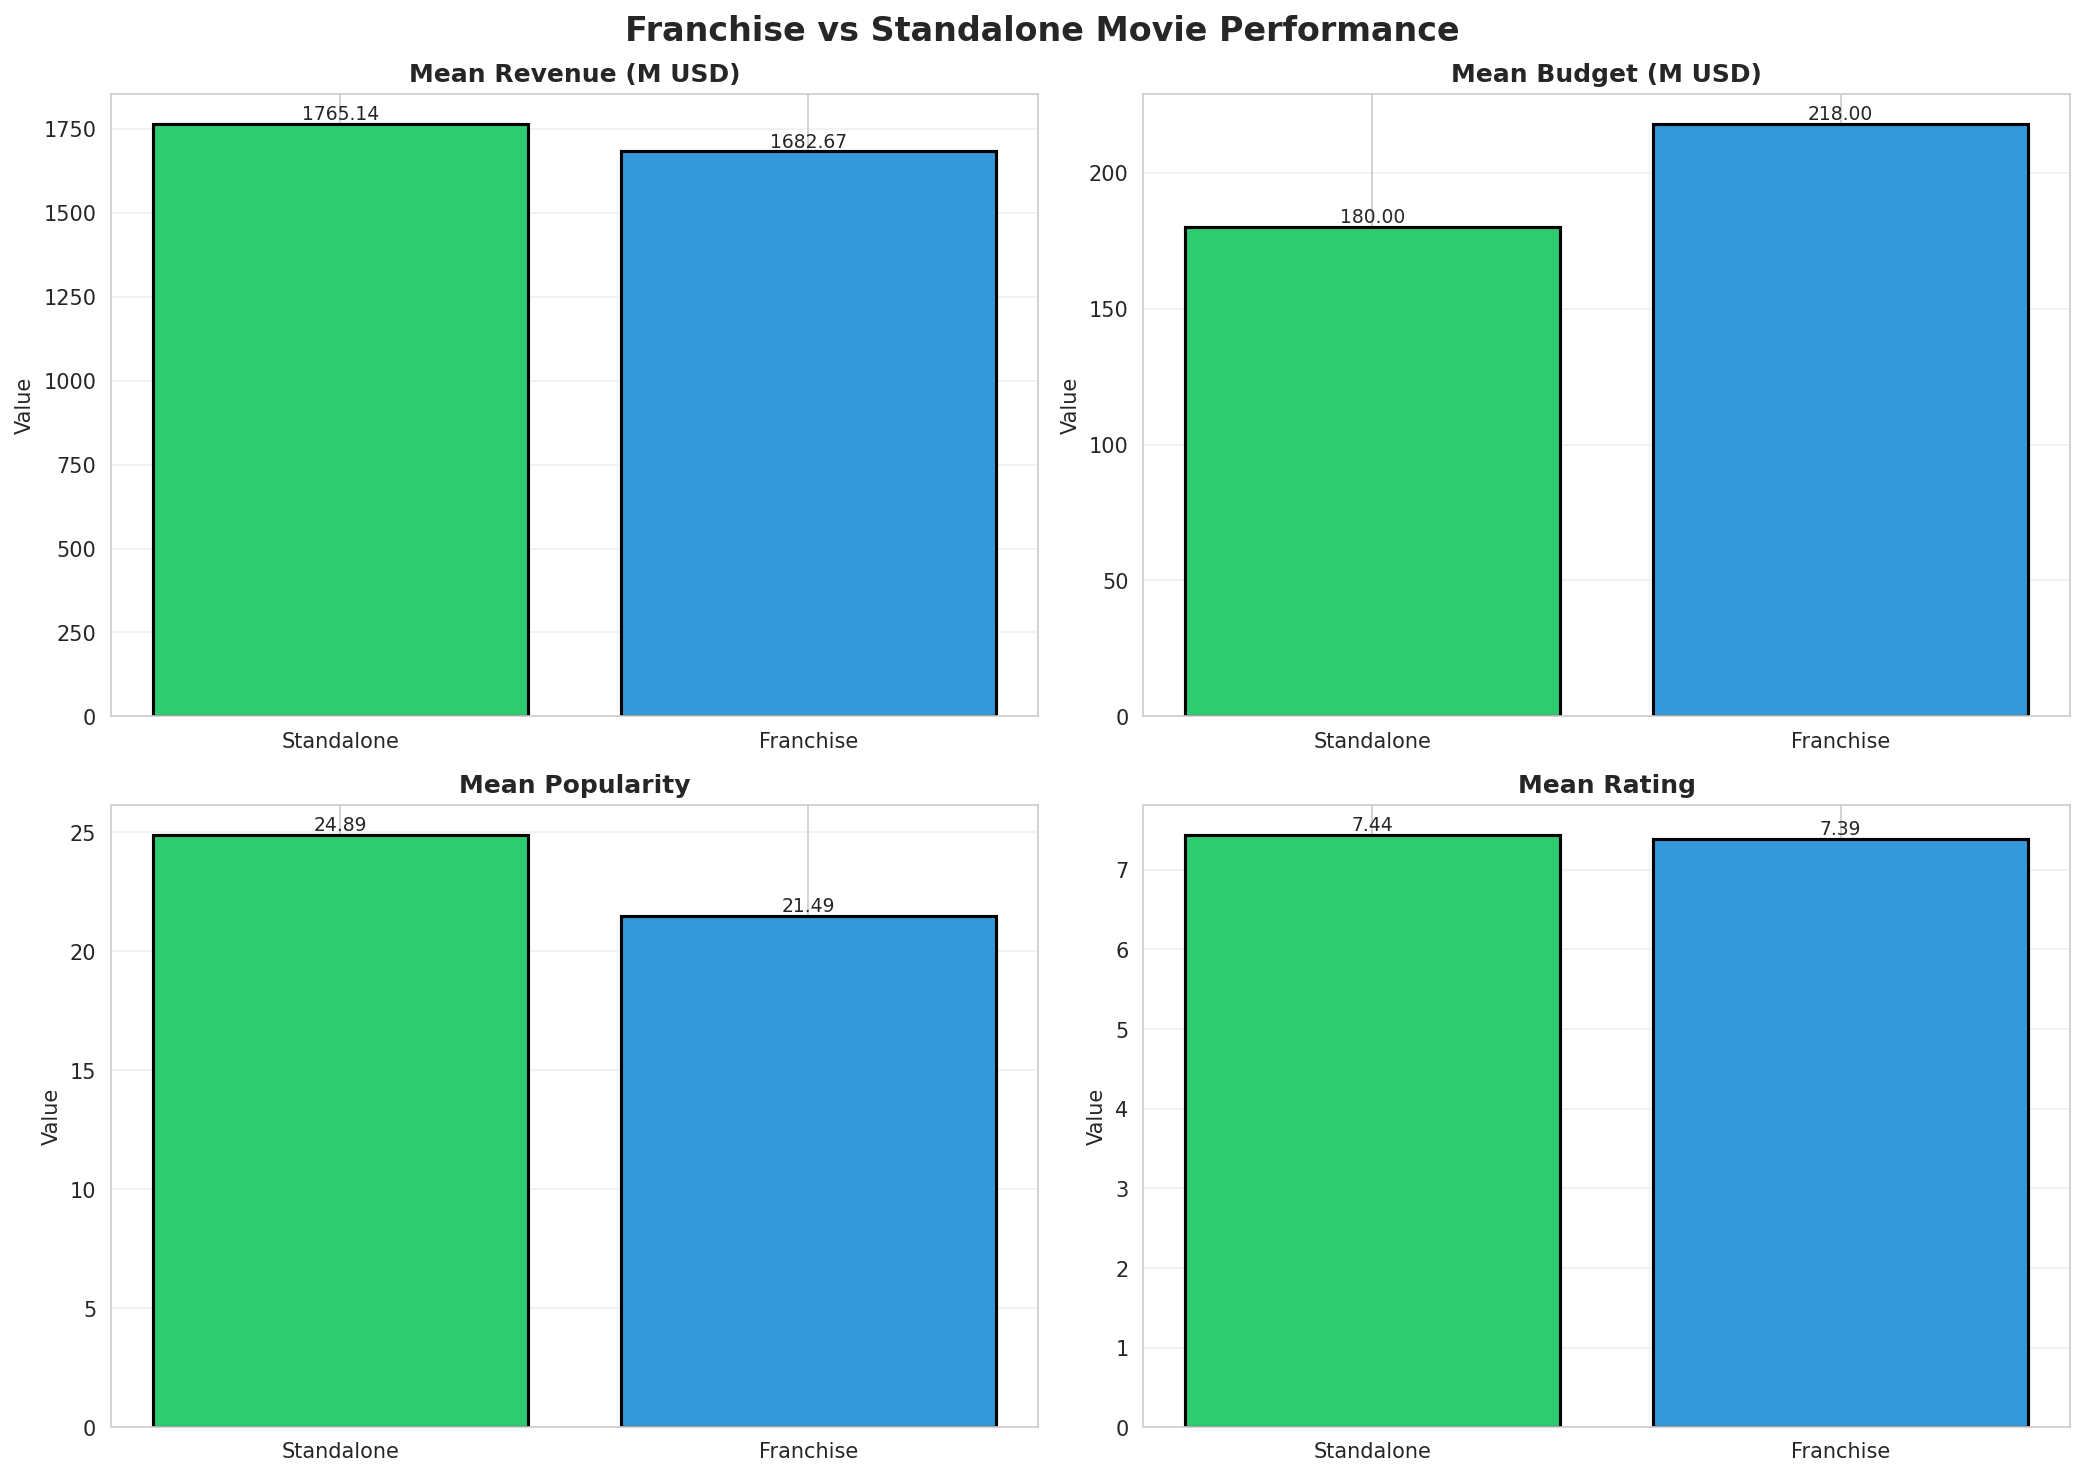


Genre Distribution


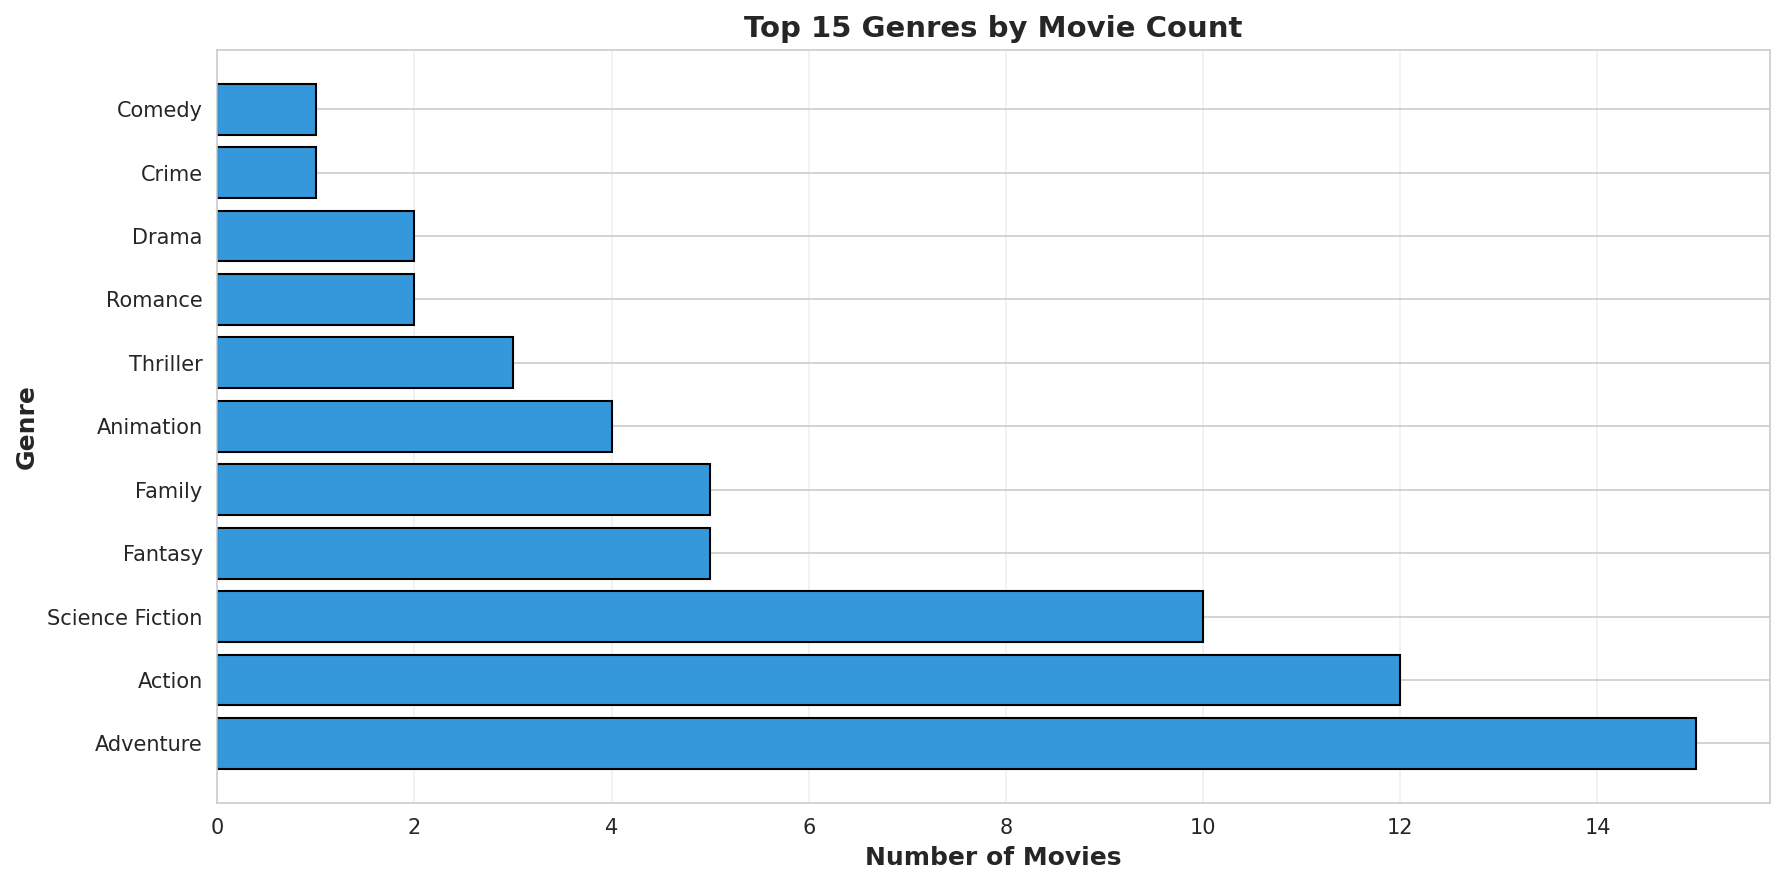


Popularity Vs Rating


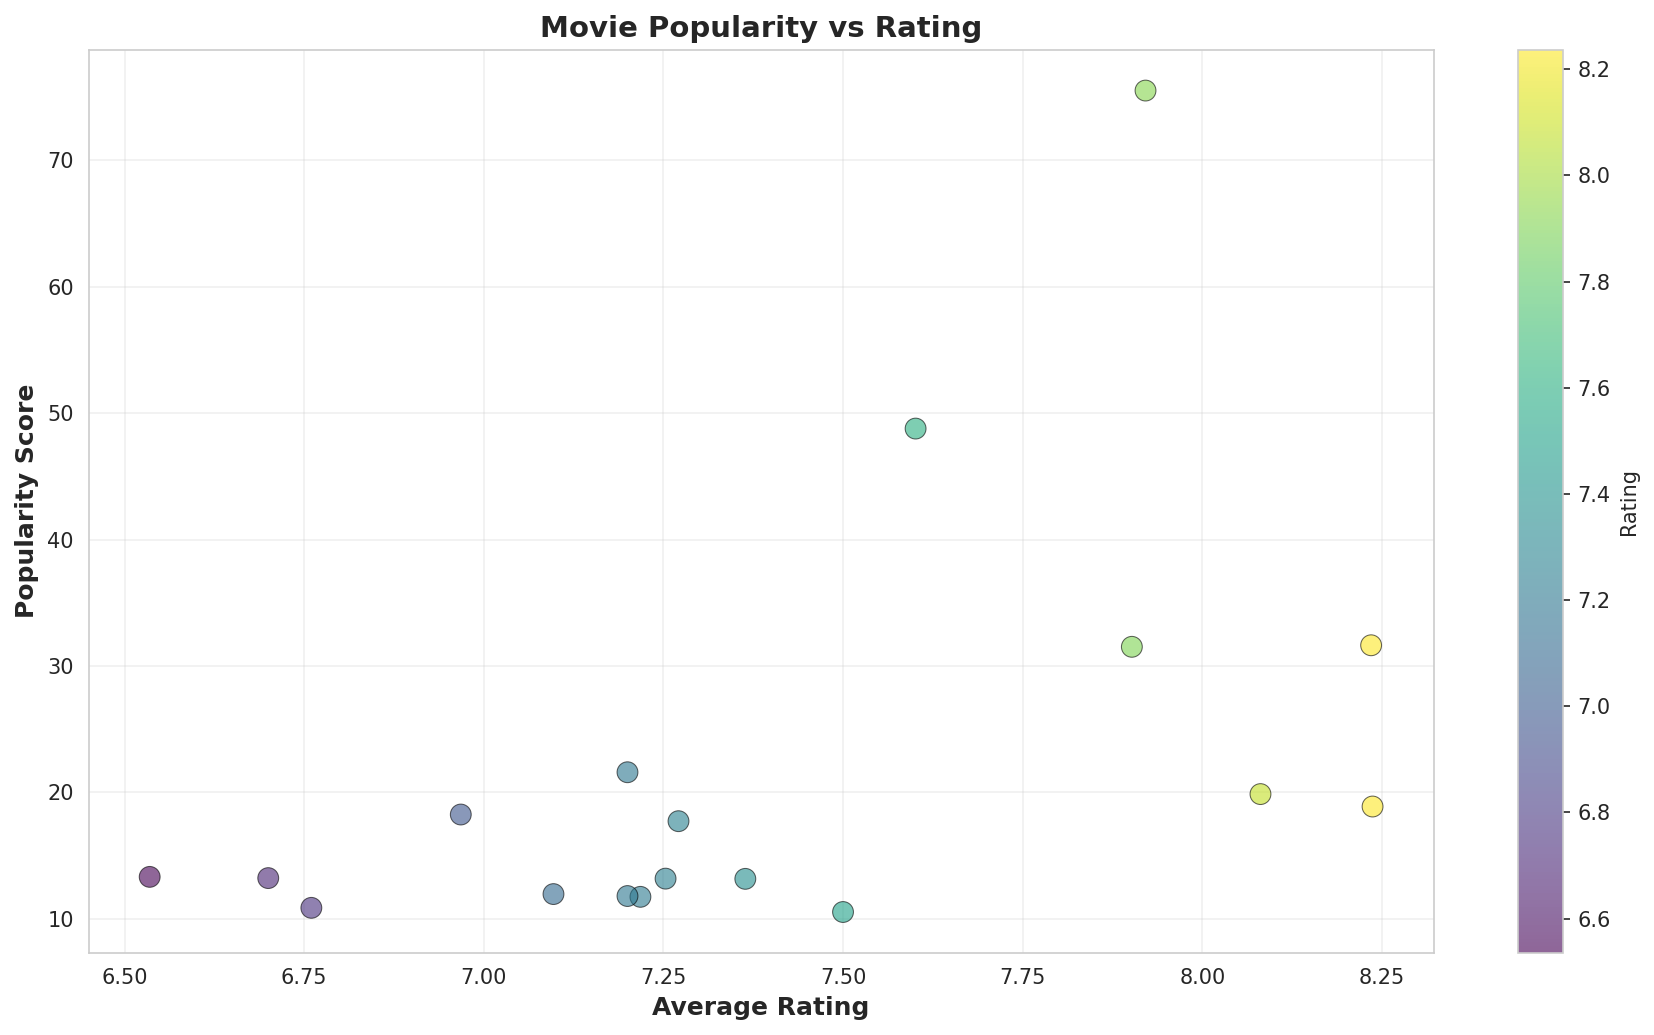


Revenue Vs Budget


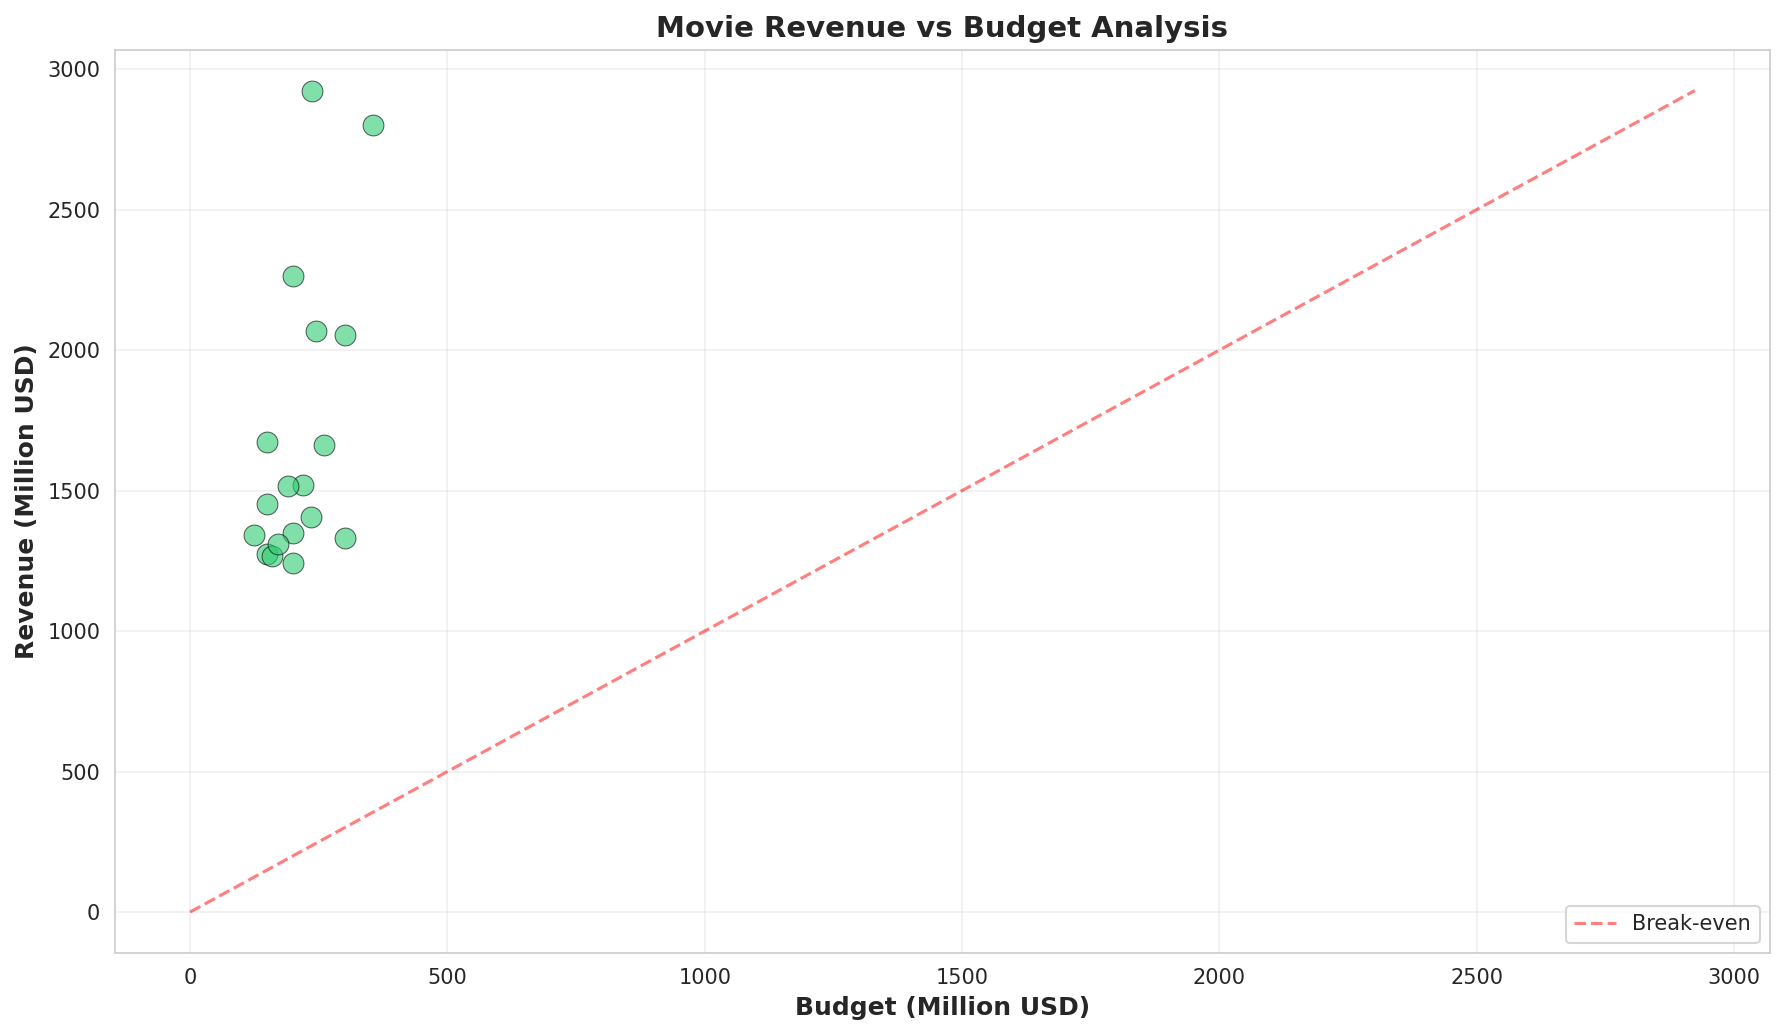


Roi Distribution


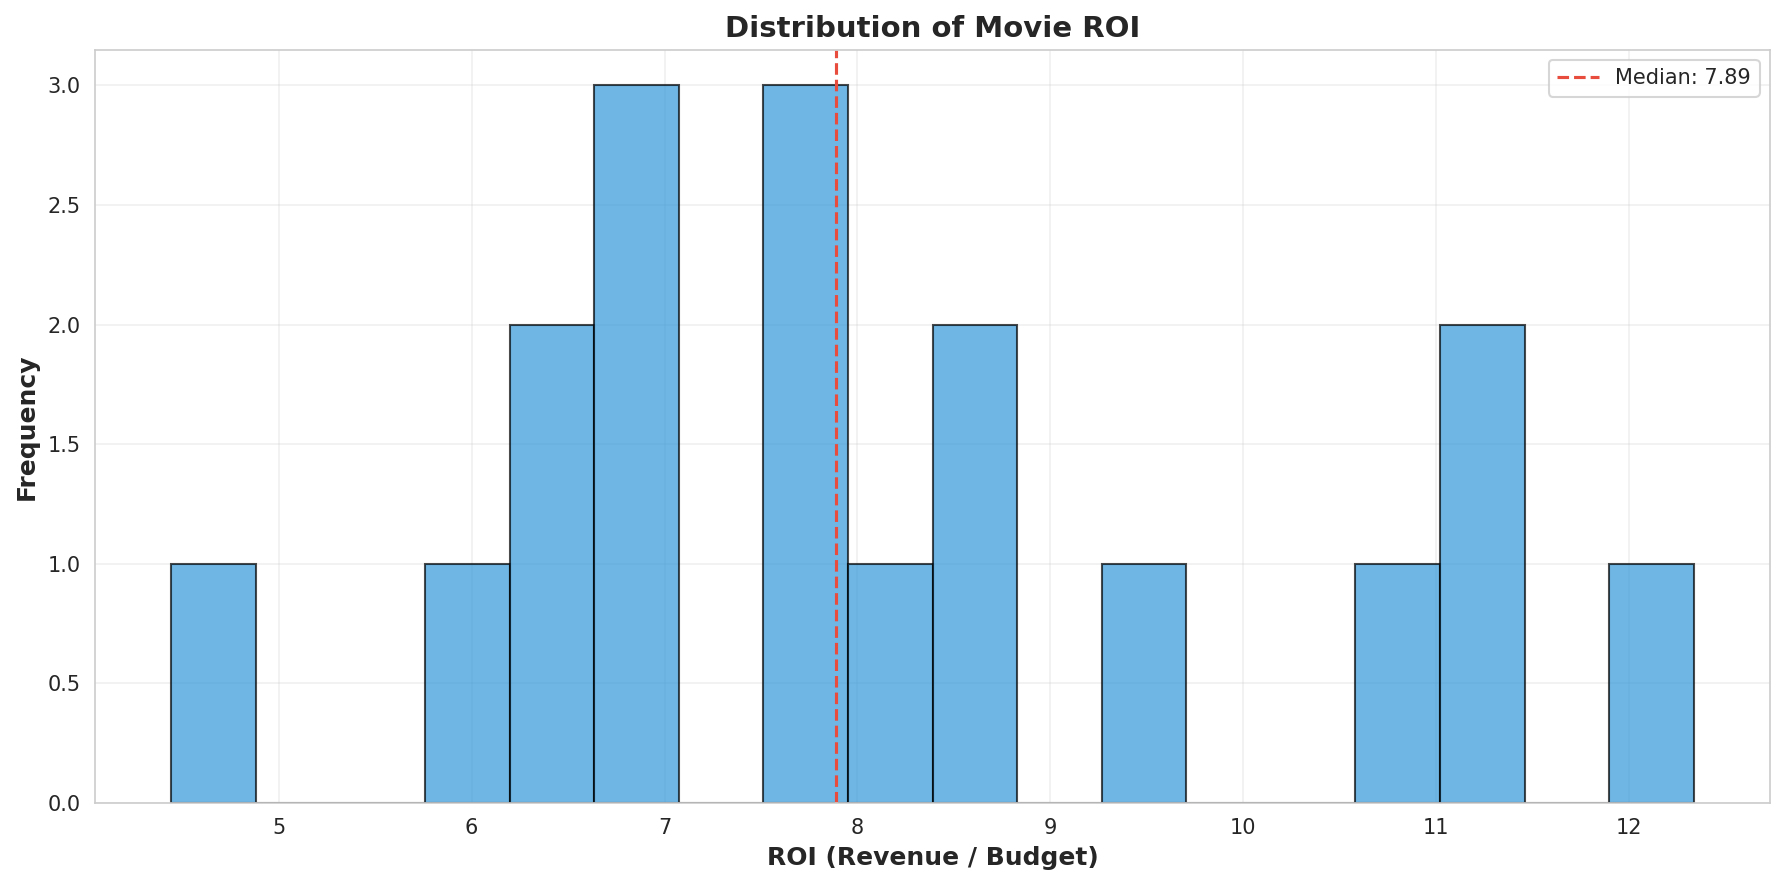


Top Franchises


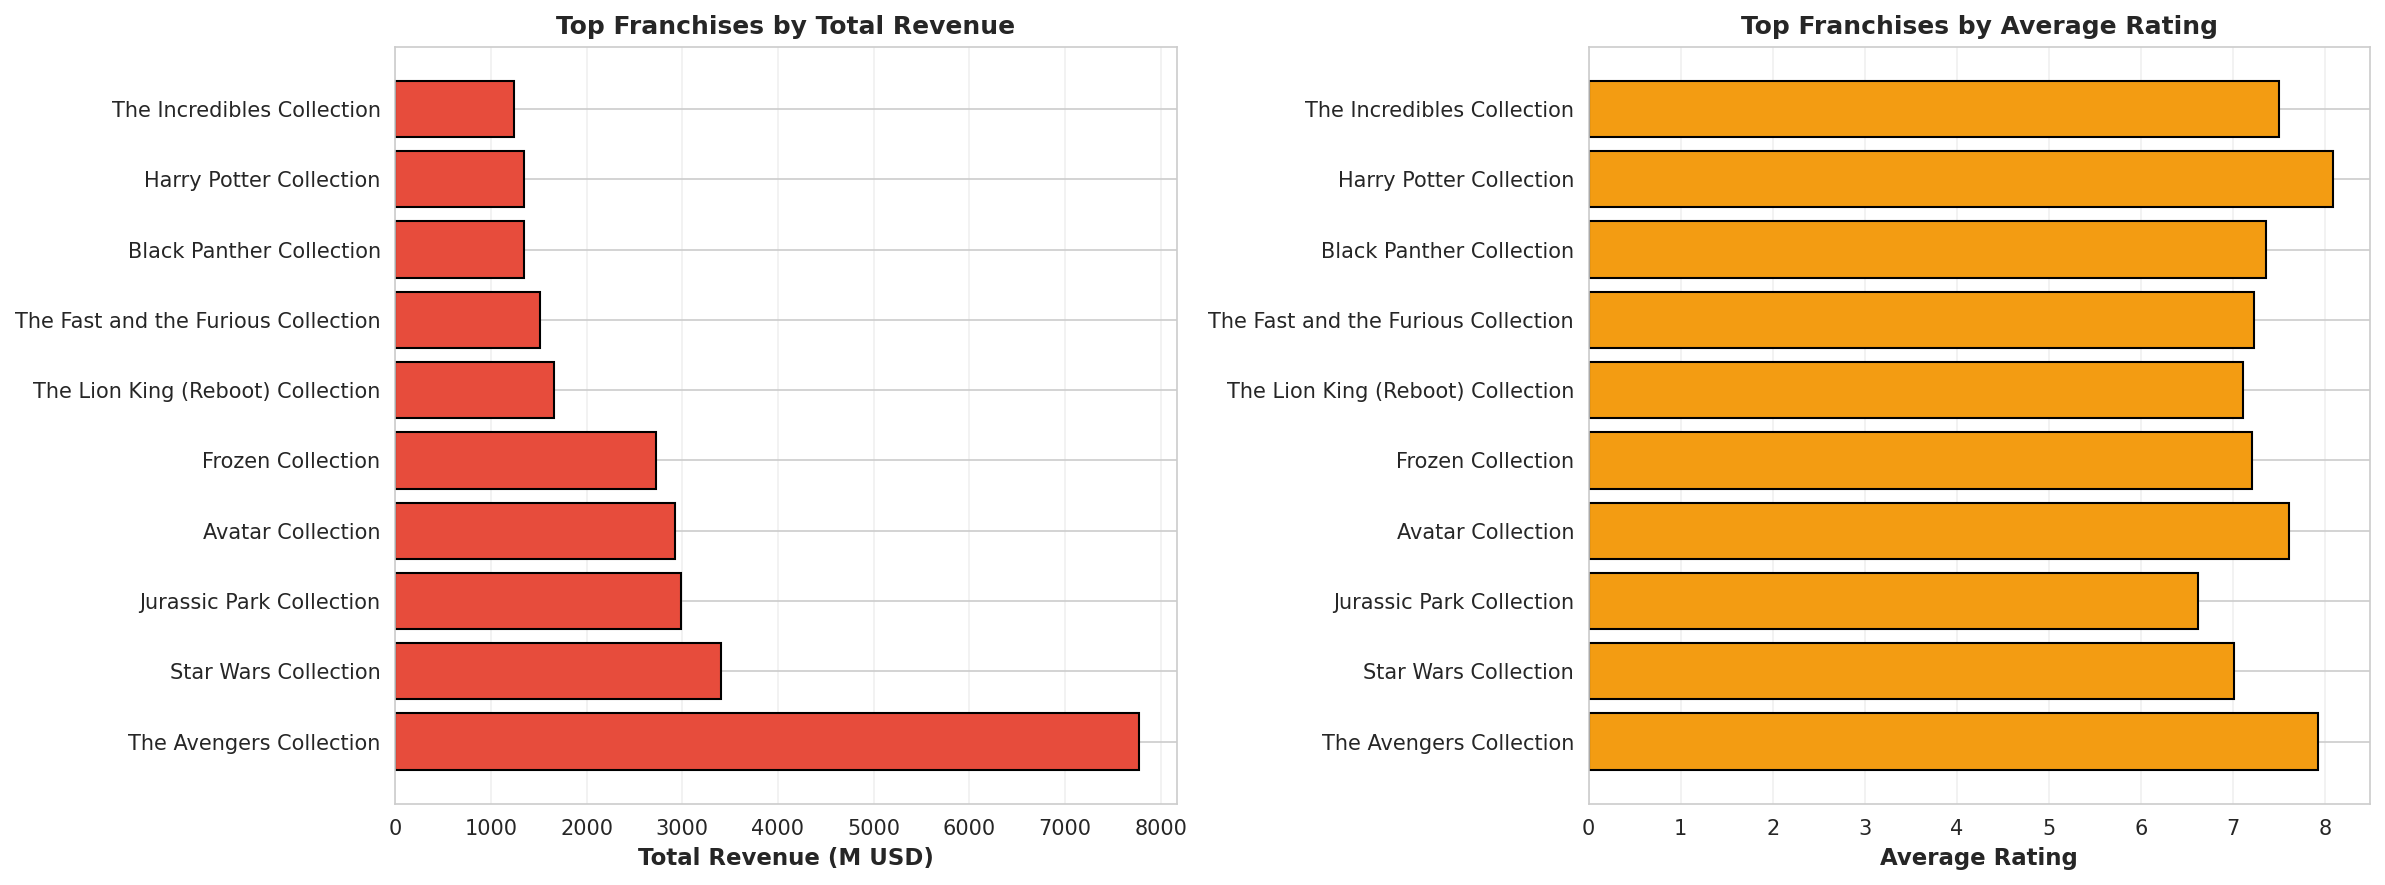


Done!


In [ ]:
# TMDB Movie Analysis Pipeline

import sys
import warnings
warnings.filterwarnings('ignore')
sys.path.append('scripts')

from pyspark.sql import SparkSession
from IPython.display import Image, display
from pathlib import Path

# Run Pipeline
from pipeline import TMDBPipeline
TMDBPipeline().run_full_pipeline()

# Create Spark Session to Read Results
spark = SparkSession.builder \
    .appName("View Results") \
    .config("spark.driver.host", "localhost") \
    .getOrCreate()

analysis_path = Path('data/analysis')

# Rankings
print("\nHIGHEST REVENUE MOVIES:")
spark.read.parquet(str(analysis_path / 'ranking_highest_revenue.parquet')).show(10, truncate=False)

print("\nMOST PROFITABLE MOVIES:")
spark.read.parquet(str(analysis_path / 'ranking_highest_profit.parquet')).show(10, truncate=False)

print("\nBEST ROI MOVIES:")
spark.read.parquet(str(analysis_path / 'ranking_highest_roi.parquet')).show(10, truncate=False)

print("\nHIGHEST RATED MOVIES:")
spark.read.parquet(str(analysis_path / 'ranking_highest_rated.parquet')).show(10, truncate=False)

print("\nMOST POPULAR MOVIES:")
spark.read.parquet(str(analysis_path / 'ranking_most_popular.parquet')).show(10, truncate=False)

# Franchise Analysis
print("\nFRANCHISE VS STANDALONE:")
spark.read.parquet(str(analysis_path / 'franchise_comparison.parquet')).show(truncate=False)

print("\nTOP FRANCHISES:")
spark.read.parquet(str(analysis_path / 'top_franchises.parquet')).show(10, truncate=False)

# Director Analysis
print("\nTOP DIRECTORS:")
spark.read.parquet(str(analysis_path / 'top_directors.parquet')).show(10, truncate=False)

# Cleaned Data Sample
print("\nCLEANED DATA SAMPLE:")
df = spark.read.parquet('data/processed/movies_clean.parquet')
df.select('title', 'genres', 'belongs_to_collection', 'budget_musd', 'revenue_musd', 'director').show(10, truncate=40)

# Visualizations
print("\nVISUALIZATIONS:")
for viz in sorted(Path('visualizations').glob('*.png')):
    print(f"\n{viz.stem.replace('_', ' ').title()}")
    display(Image(filename=str(viz), width=800))

# Cleanup
spark.stop()
print("\nDone!")
